# The +10% $ -10% momerr analysis!

## Data Generation
### The perturbed tracking datasets analyzed below are explicitly generated by running the standalone script: `01_Data_Perturbation.ipynb` This notebook loads the static binary files directly from disk to evaluate model stability

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import joblib
import json
from sklearn.metrics import accuracy_score, log_loss, roc_curve, auc

In [2]:
# 1. Clear Master Paths & Configuration Constants
MODEL_PATH = "/Users/malikfarouh/Documents/ML_workspace/model/TrkQual_BDT1_v2.0.json"
BASE_PATH  = "/Users/malikfarouh/Documents/ML_workspace/data/trkqual_tree_v2.0_training.root"
TREE_NAME  = "trkqualtree"
TRKQUAL_CUT = 0.92

# Load the model exactly once
#model = JSON.load(MODEL_PATH)

model = xgb.XGBClassifier()
model.load_model(MODEL_PATH)

# 2. Master Extraction Tool
def get_predictions(file_path):
    """Opens any target file and extracts model score probabilities matching the original training script pipeline."""
    # Opens the file directory and targets the tree object dynamically
    trkqual_tree = uproot.open(file_path)[TREE_NAME]
    
    local_mom_res = []
    local_features = []
    
    for batch in trkqual_tree.iterate(step_size="10 MB", library='ak'):
        
        # Calculate the momentum components identically to your training script
        batch['trk_ent.mom'] = (batch['trk_ent.mom.fCoordinates.fX']**2 + 
                                batch['trk_ent.mom.fCoordinates.fY']**2 + 
                                batch['trk_ent.mom.fCoordinates.fZ']**2)**0.5
                                
        batch['trk_ent_mc.mom'] = (batch['trk_ent_mc.mom.fCoordinates.fX']**2 + 
                                   batch['trk_ent_mc.mom.fCoordinates.fY']**2 + 
                                   batch['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
        
        mom_res_batch = batch['trk_ent.mom'] - batch['trk_ent_mc.mom']
        
        # Apply selection masks
        track_mask = (batch['trk.status'] > 0) & (batch['trk.goodfit'] == 1) & (~np.isnan(batch['trk_ent_pars.t0err']))
        
        # Convert each column to a true NumPy array first so .T works perfectly!
        nactive_np = batch['trk.nactive'][track_mask].to_numpy()
        
        x_batch = np.vstack((
            nactive_np,
            nactive_np / batch['trk.nhits'][track_mask].to_numpy(),
            batch['trk_ent_pars.t0err'][track_mask].to_numpy(),
            batch['trk.nnullambig'][track_mask].to_numpy() / nactive_np,
            batch['trk.fitcon'][track_mask].to_numpy(),
            batch['trk_ent.momerr'][track_mask].to_numpy(),
            batch['trk.nmatactive'][track_mask].to_numpy() / nactive_np
        )).T
        
        # Append arrays to local accumulator lists
        local_mom_res.extend(mom_res_batch[track_mask].to_numpy())
        local_features.extend(x_batch)
        
    # Convert lists to solid matrix blocks for the model
    local_mom_res = np.array(local_mom_res)
    X = np.array(local_features)
    
    # Run pre-trained BDT classifier predictions over the matching shape
    predictions = model.predict_proba(X)[:, 1]
    
    return local_mom_res, X, predictions

# # 3. Process All Tracks Instantly 
res_original, x_original_full, y_pred_orig = get_predictions(BASE_PATH)

# Using your exact dynamic path strings, but passing them directly to your variable slots
res_up, x_up, y_pred_up = get_predictions(BASE_PATH.replace('.root', '_momerr_plus10pct.root'))
res_down, x_down, y_pred_down = get_predictions(BASE_PATH.replace('.root', '_momerr_minus10pct.root'))
res_up50, x_up50, y_pred_up50 = get_predictions(BASE_PATH.replace('.root', '_momerr_plus50pct.root'))
res_down50, x_down50, y_pred_down50 = get_predictions(BASE_PATH.replace('.root', '_momerr_minus50pct.root'))

# 4. Generate the Ground Truth Labels Natively
with uproot.open(f"{BASE_PATH}:{TREE_NAME}") as tree:
    arrays = tree.arrays(library="np")
    mom_ent = np.sqrt(arrays['trk_ent.mom.fCoordinates.fX']**2 + arrays['trk_ent.mom.fCoordinates.fY']**2 + arrays['trk_ent.mom.fCoordinates.fZ']**2)
    mom_mc  = np.sqrt(arrays['trk_ent_mc.mom.fCoordinates.fX']**2 + arrays['trk_ent_mc.mom.fCoordinates.fY']**2 + arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)
    mom_res_filtered = (mom_ent - mom_mc)[(mom_ent - mom_mc > -0.25) & (mom_ent - mom_mc < 0.25) | (mom_ent - mom_mc > 0.7)]
    
    y_full_filtered = np.zeros(len(mom_res_filtered))
    y_full_filtered[(mom_res_filtered > -0.25) & (mom_res_filtered < 0.25)] = 1

N_signal = (y_full_filtered == 1).sum()
N_background = (y_full_filtered == 0).sum()

print(f"Data processing complete. Stored tracking metrics for {len(y_pred_orig):,} tracks.")

Data processing complete. Stored tracking metrics for 452,686 tracks.


In [3]:
print("Are the data arrays identical?:", (res_up == res_down).all())

Are the data arrays identical?: True


In [4]:
# 1. Print Baseline Total Sample Overview
print(f"Signal tracks: {N_signal:,}")
print(f"Background tracks: {N_background:,}")
print(f"Total tracks in dataset: {len(y_pred_orig):,}\n")
print(f"{'':<30s} {'Mean shift':>12s} {'± std':>8s}     {'Changed':>8s}   {'%':>6s}")
print("-" * 75)

# 2. Loop through up/down shifts using the true labels 
for label, y_pred in [('momerr +10%', y_pred_up), ('momerr -10%', y_pred_down)]:

    delta = y_pred - y_pred_orig
    bdt_pass_orig = y_pred_orig >= TRKQUAL_CUT
    bdt_pass_new  = y_pred >= TRKQUAL_CUT
    changed = (bdt_pass_orig != bdt_pass_new).sum()
    
    true_signal_mask = (res_original > -0.25) & (res_original < 0.25)
    true_background_mask = (res_original > 0.7)
    
    # Extract the signal vs background counts safely using your new size-matched masks
    drift_mask = bdt_pass_orig != bdt_pass_new
    
    n_sig_changed = (drift_mask & true_signal_mask).sum()
    n_bkg_changed = (drift_mask & true_background_mask).sum()
    
    print(f"{label:30s} {delta.mean():>12.6f}   {delta.std():>8.6f}   {changed:>8}   {changed/len(delta)*100:>6.2f}%\n")
    print(f"Of the {changed:,} changed tracks: True Signal = {n_sig_changed:,} | True Background = {n_bkg_changed:,}\n")

Signal tracks: 303,991
Background tracks: 13,449
Total tracks in dataset: 452,686

                                 Mean shift    ± std      Changed        %
---------------------------------------------------------------------------
momerr +10%                       -0.027364   0.033419      16691     3.69%

Of the 16,691 changed tracks: True Signal = 12,685 | True Background = 31

momerr -10%                        0.028005   0.035217      17849     3.94%

Of the 17,849 changed tracks: True Signal = 13,291 | True Background = 56



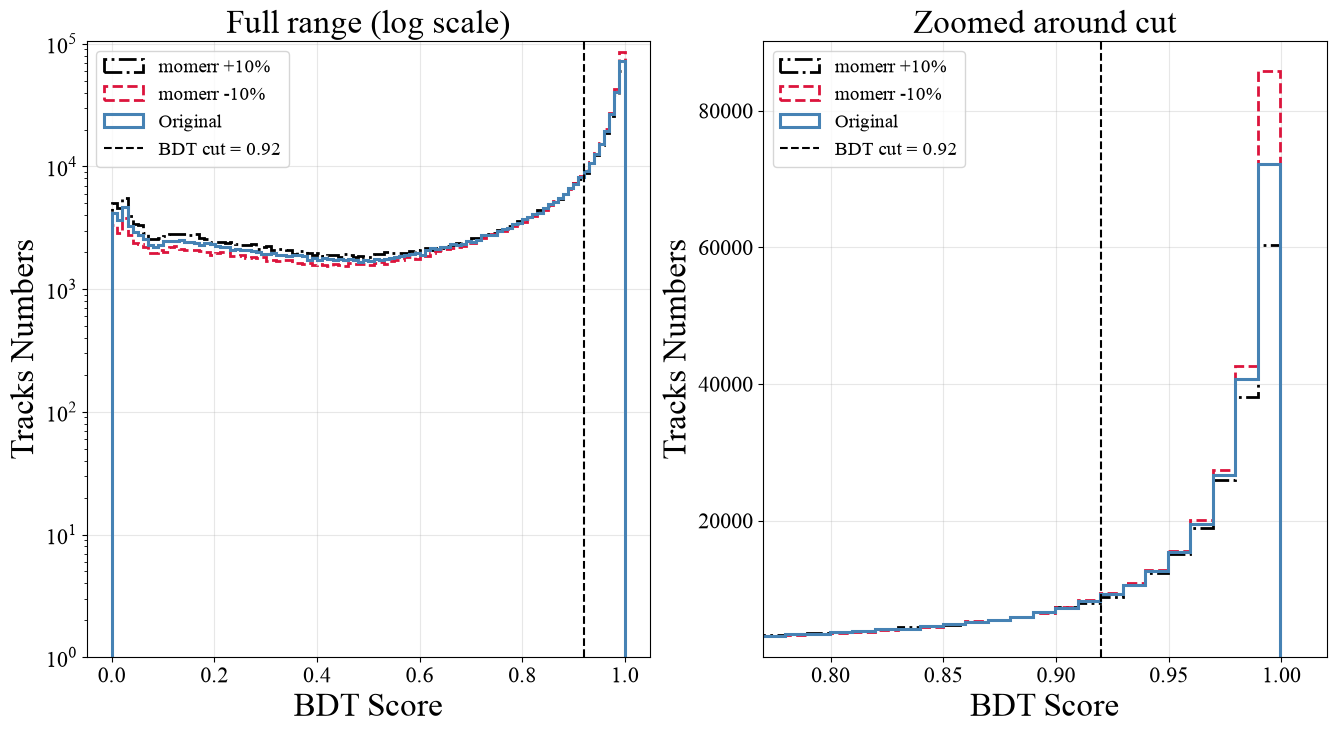

In [5]:
# Run this to match default LaTeX text
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42

# Scale font sizes up Figures  after LaTeX
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14
})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
#fig.suptitle("BDT Score Distribution: Original vs momerr Perturbations (±10%)")

for ax, title, xlim in zip(axes, ['Full range (log scale)', 'Zoomed around cut'], [None, (TRKQUAL_CUT - 0.15, TRKQUAL_CUT + 0.1)]):
    
    ax.hist(y_pred_up, bins=100, color="black", linestyle="-.", histtype='step', linewidth=2.0, label='momerr +10%') 
    ax.hist(y_pred_down, bins=100, color="crimson", linestyle='--', linewidth=2.0, histtype='step', label='momerr -10%')
    ax.hist(y_pred_orig, bins=100, color="steelblue", histtype='step', linewidth=2.2, label='Original')
    
    ax.axvline(TRKQUAL_CUT, color="#000000", linestyle='--', linewidth=1.5, label=f'BDT cut = {TRKQUAL_CUT:.2f}')

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Tracks Numbers")
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    if xlim:
        ax.set_xlim(xlim)
        
    else:
        #ax.set_yscale('log', base = 10)
        ax.set_yscale('log')
    ax.set_ylim(bottom=1)



fig.savefig("/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/BDT_score_dis_10.pdf")

plt.show()


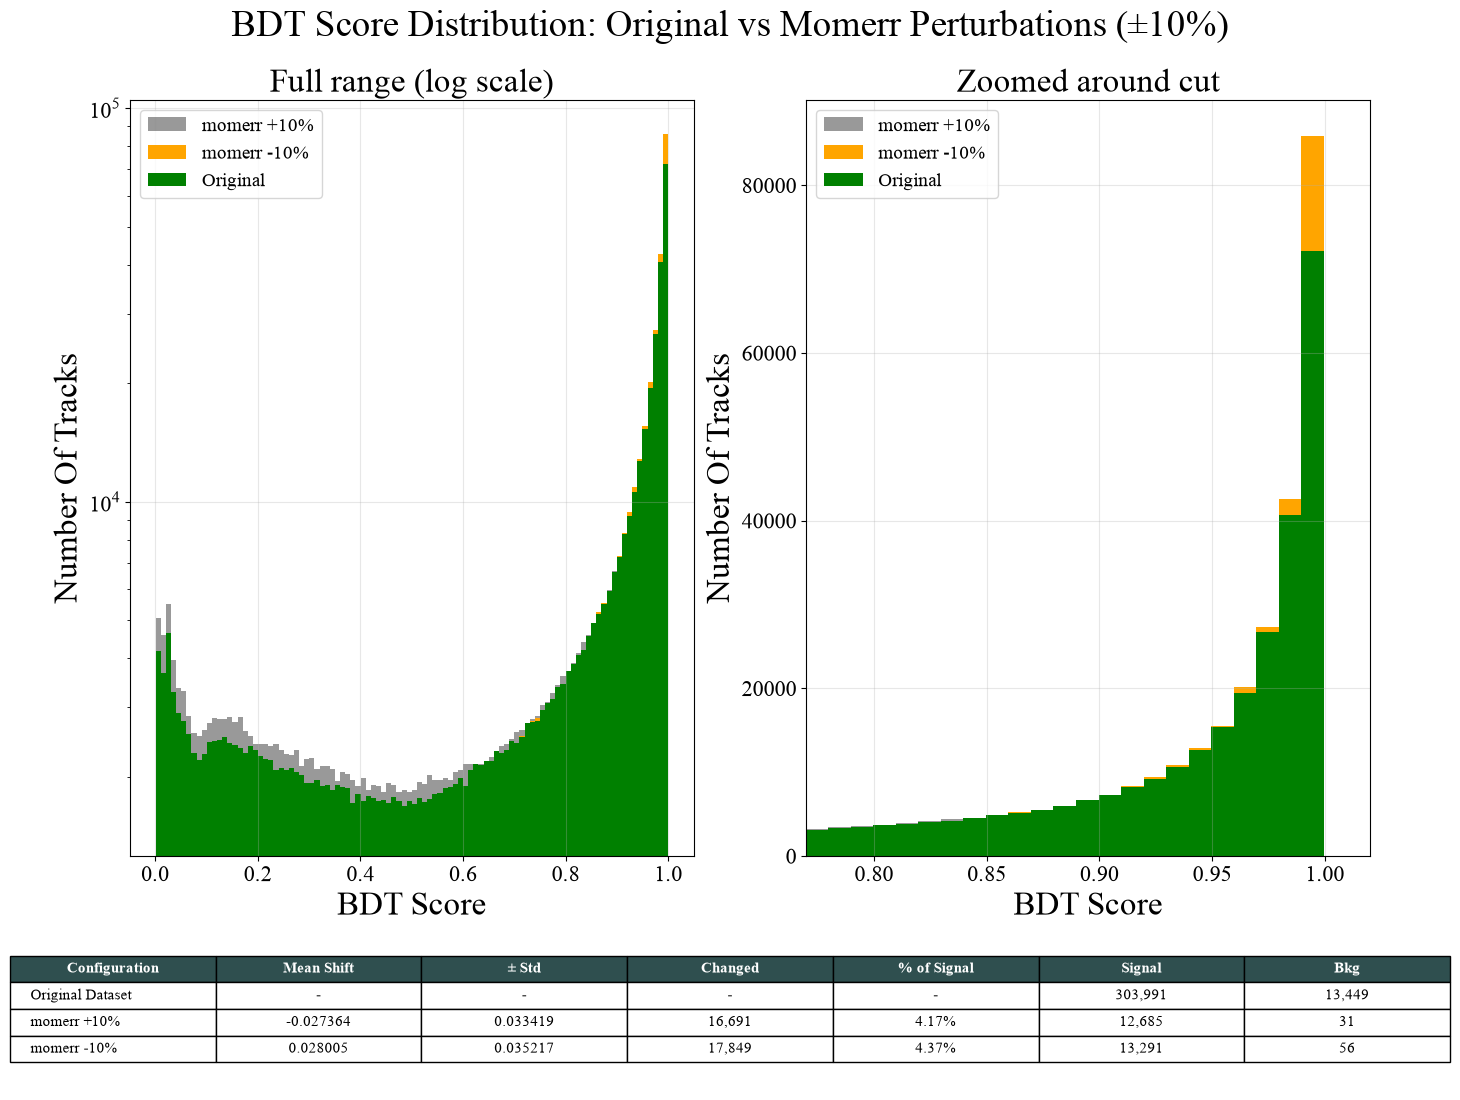

In [9]:
#reate size-matched truth masks using your actual extracted track resolution!
true_signal_mask = (res_original > -0.25) & (res_original < 0.25)
true_background_mask = (res_original > 0.7)

# # Calculations for Momerr +10%
bdt_pass_up = y_pred_up >= TRKQUAL_CUT
changed_up = (bdt_pass_orig != bdt_pass_up).sum()
drift_mask_up = bdt_pass_orig != bdt_pass_up
sig_up = (drift_mask_up & true_signal_mask).sum()
bkg_up = (drift_mask_up & true_background_mask).sum()
delta_up = y_pred_up - y_pred_orig

# # Calculations for Momerr -10%
bdt_pass_down = y_pred_down >= TRKQUAL_CUT
changed_down = (bdt_pass_orig != bdt_pass_down).sum()

drift_mask_down = bdt_pass_orig != bdt_pass_down
sig_down = (drift_mask_down & true_signal_mask).sum()
bkg_down = (drift_mask_down & true_background_mask).sum()
delta_down = y_pred_down - y_pred_orig

# 2. PLOT GENERATOR
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
#fig.suptitle("BDT Score: Original vs momerr Perturbations (±10%)", fontsize=14, fontweight='bold', y=0.98)
fig.suptitle("BDT Score Distribution: Original vs Momerr Perturbations (±10%)")

for ax, title, xlim in zip(axes, ['Full range (log scale)', 'Zoomed around cut'], [None, (TRKQUAL_CUT - 0.15, TRKQUAL_CUT + 0.10)]):
    '''ax.hist(y_pred_up, bins=100, alpha=0.5, color='orange', label='momerr +10%')
    ax.hist(y_pred_down, bins=100, alpha=0.5, color='green', label='momerr -10%')
    ax.hist(y_pred_orig, bins=100, alpha=0.9, color='black', label='Original', histtype='step', linewidth=2)'''

    # 1. ORANGE FILL: Looks bright on screen, turns into a light gray background shape in print
    ax.hist(y_pred_up, bins=100, histtype='barstacked', color='black', alpha=0.4, label='momerr +10%')
        
    # 2. GREEN DASHED LINE: Vibrant green on screen, prints as a unique dashed outline over the fill
    ax.hist(y_pred_down, bins=100, histtype='bar', color='orange', linestyle='--', linewidth=1.5, label='momerr -10%')
        
    # 3. SOLID BLACK LINE: Classic benchmark that anchors the entire graph in both color and print
    ax.hist(y_pred_orig, bins=100, histtype='bar', color='green', linestyle='-', linewidth=2.0, label='Original')


    
    '''ax.axvline(TRKQUAL_CUT, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {TRKQUAL_CUT:.2f}')
    ax.set_xlabel("BDT Score", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper left', fontsize=11)'''

    ax.set_xlabel("BDT Score")
    ax.set_ylabel("Number Of Tracks")
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# 3. SUMMARY TABLE
table_data = [
    ["Original Dataset", "-", "-", "-", "-", f"{N_signal:,}", f"{N_background:,}"],
    ["momerr +10%", f"{delta_up.mean():.6f}", f"{delta_up.std():.6f}", f"{changed_up:,}", f"{sig_up/N_signal*100:.2f}%", f"{sig_up:,}", f"{bkg_up:,}"],
    ["momerr -10%", f"{delta_down.mean():.6f}", f"{delta_down.std():.6f}", f"{changed_down:,}", f"{sig_down/N_signal*100:.2f}%", f"{sig_down:,}", f"{bkg_down:,}"]
]

columns = ["Configuration", "Mean Shift", "± Std", "Changed", "% of Signal", "Signal", "Bkg"]

table_ax = fig.add_axes([0.05, -0.22, 0.9, 0.18])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11)
summary_table.scale(1.0, 1.6)

# Table Custom Header Themes
for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.04)
plt.show()


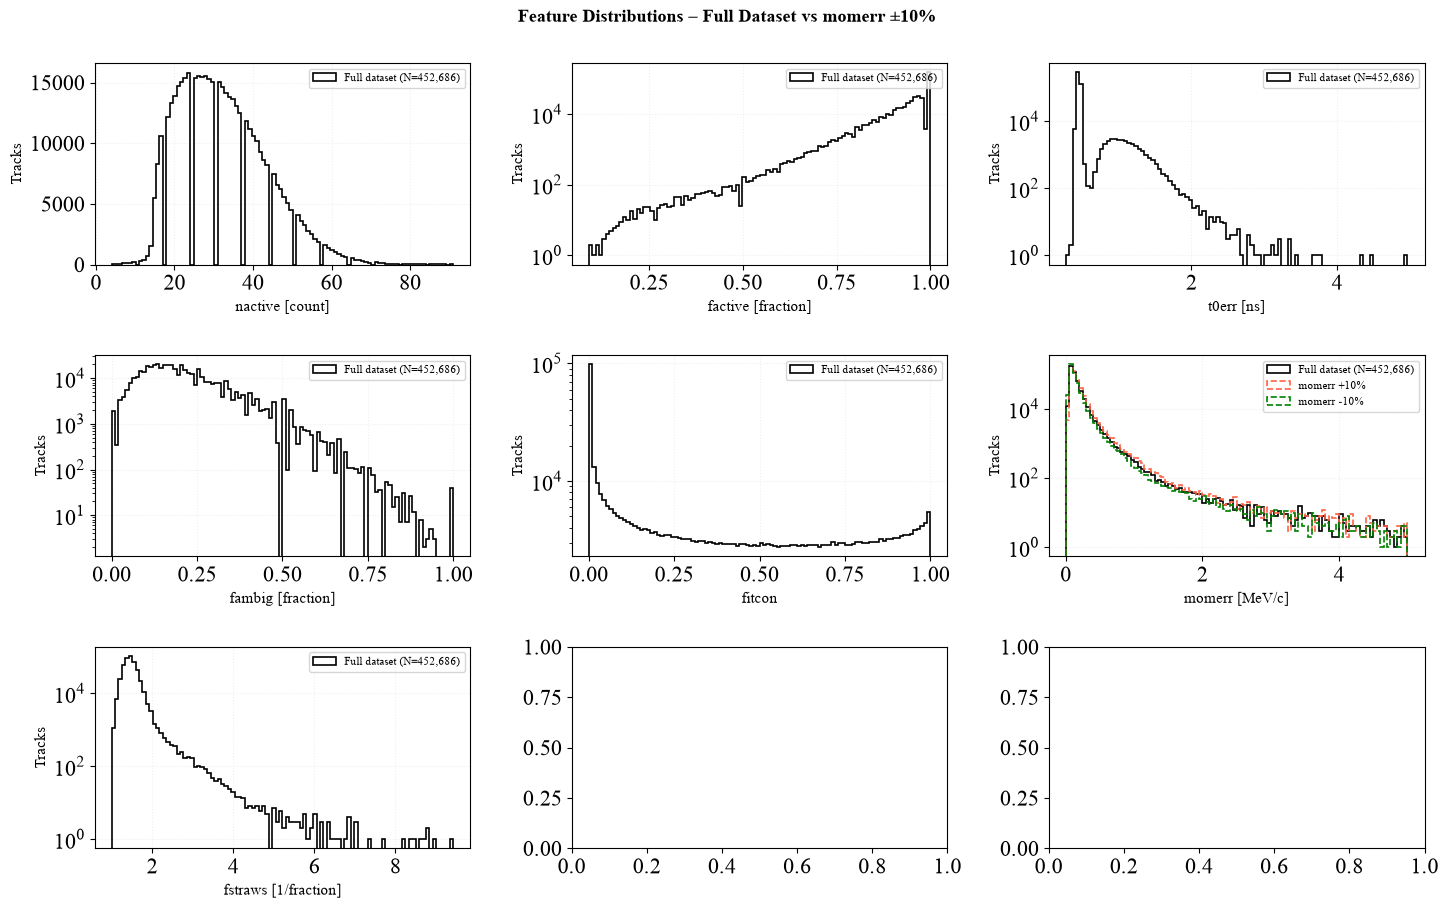

In [10]:
# 1. Clean configuration maps
input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
units = [" [count]", " [fraction]", " [ns]", " [fraction]", "", " [MeV/c]", " [1/fraction]"]
log_flags = [False, True, True, True, True, True, True]  # Match the old panel scales perfectly
momerr_idx = input_var_names.index('momerr')

fig, axs = plt.subplots(3, 3, figsize=(15, 9.5))
fig.subplots_adjust(hspace=0.45, wspace=0.25)
fig.suptitle("Feature Distributions – Full Dataset vs momerr ±10%", fontsize=13, fontweight='bold', y=0.97)

# 2. simple loop
for i_var, name in enumerate(input_var_names):
    ax = axs.flatten()[i_var]
    
    # Clean range limits
    lims = (float(x_original_full[:, i_var].min()), float(x_original_full[:, i_var].max()))
    if name == "momerr": lims = (0, 5)  # Zooms into the critical physics tail region
    
    # Draw original baseline control dataset
    ax.hist(x_original_full[:, i_var], bins=100, range=lims, log=log_flags[i_var], 
            histtype='step', color='black', label=f'Full dataset (N={len(x_original_full):,})', linewidth=1.2)
    
    # Overlay perturbations exclusively for momerr
    if i_var == momerr_idx:
        ax.hist(x_up[:, i_var], bins=100, range=lims, log=True, histtype='step', color='tomato', label='momerr +10%', linestyle='--', linewidth=1.2)
        ax.hist(x_down[:, i_var], bins=100, range=lims, log=True, histtype='step', color='green', label='momerr -10%', linestyle='--', linewidth=1.2)
        
    ax.set_xlabel(f"{name}{units[i_var]}", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2, linestyle=':')
    
plt.tight_layout()
plt.show()

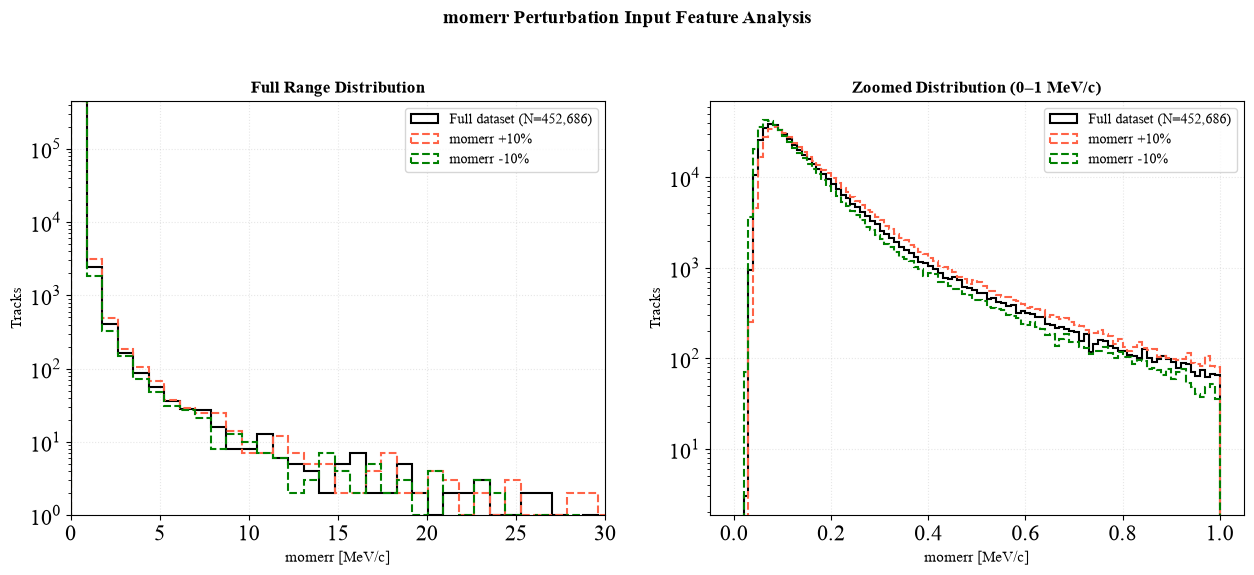

In [11]:
# fetch the active momerr index and define tracking parameters
i = input_var_names.index('momerr')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

plot_params = [
    (x_original_full[:, i], 'black', f'Full dataset (N={len(x_original_full):,})', '-'),
    (x_up[:, i], 'tomato', 'momerr +10%', '--'),
    (x_down[:, i], 'green', 'momerr -10%', '--')
]

# Compute true dynamic range limits to replace the missing x_mins/x_maxs lists
f_min, f_max = float(x_original_full[:, i].min()), float(x_original_full[:, i].max())

# 2. Loop through both axes to apply the data overlays cleanly
for ax in [ax1, ax2]:
    for data, color, label, style in plot_params:
        # Swapped out missing boundary lists for dynamic ranges
        hist_range = (f_min, f_max) if ax == ax1 else (0.0, 1.0)
        
        ax.hist(data, bins=100, range=hist_range,
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=1.5)
        
    ax.set_ylabel("Tracks", fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(alpha=0.3, linestyle=':')

# 3. Individual Panel Customization 
ax1.set_title("Full Range Distribution", fontweight='bold', fontsize=12)
ax1.set_xlabel("momerr [MeV/c]", fontsize=11)
ax1.set_xlim(0, 30) # Caps wide empty tail space to keep visual focus clean
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold', fontsize=12)
ax2.set_xlabel("momerr [MeV/c]", fontsize=11)

fig.suptitle("momerr Perturbation Input Feature Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

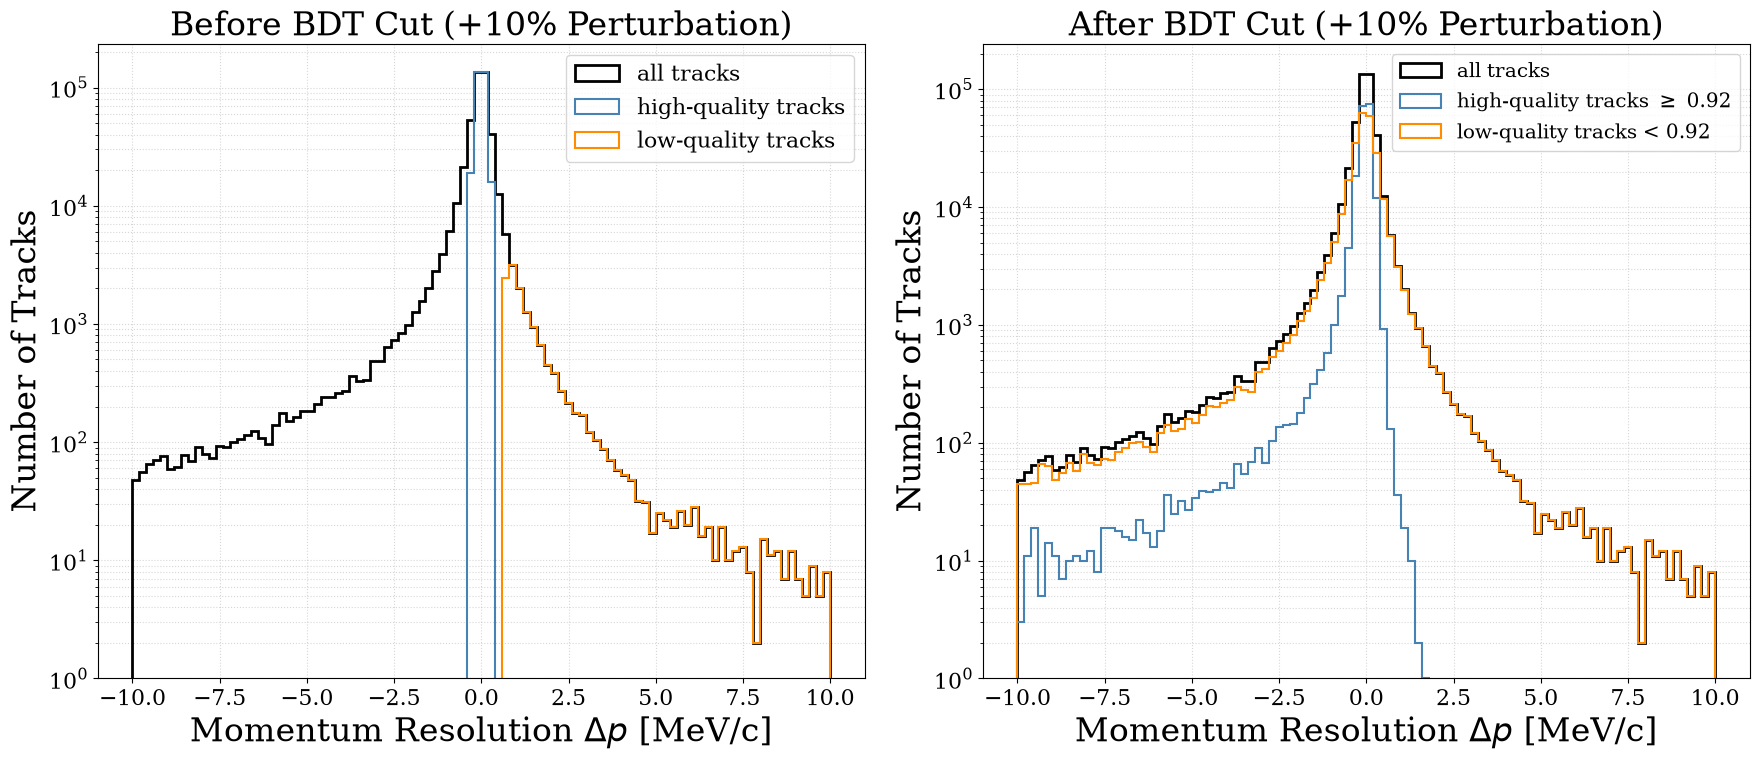

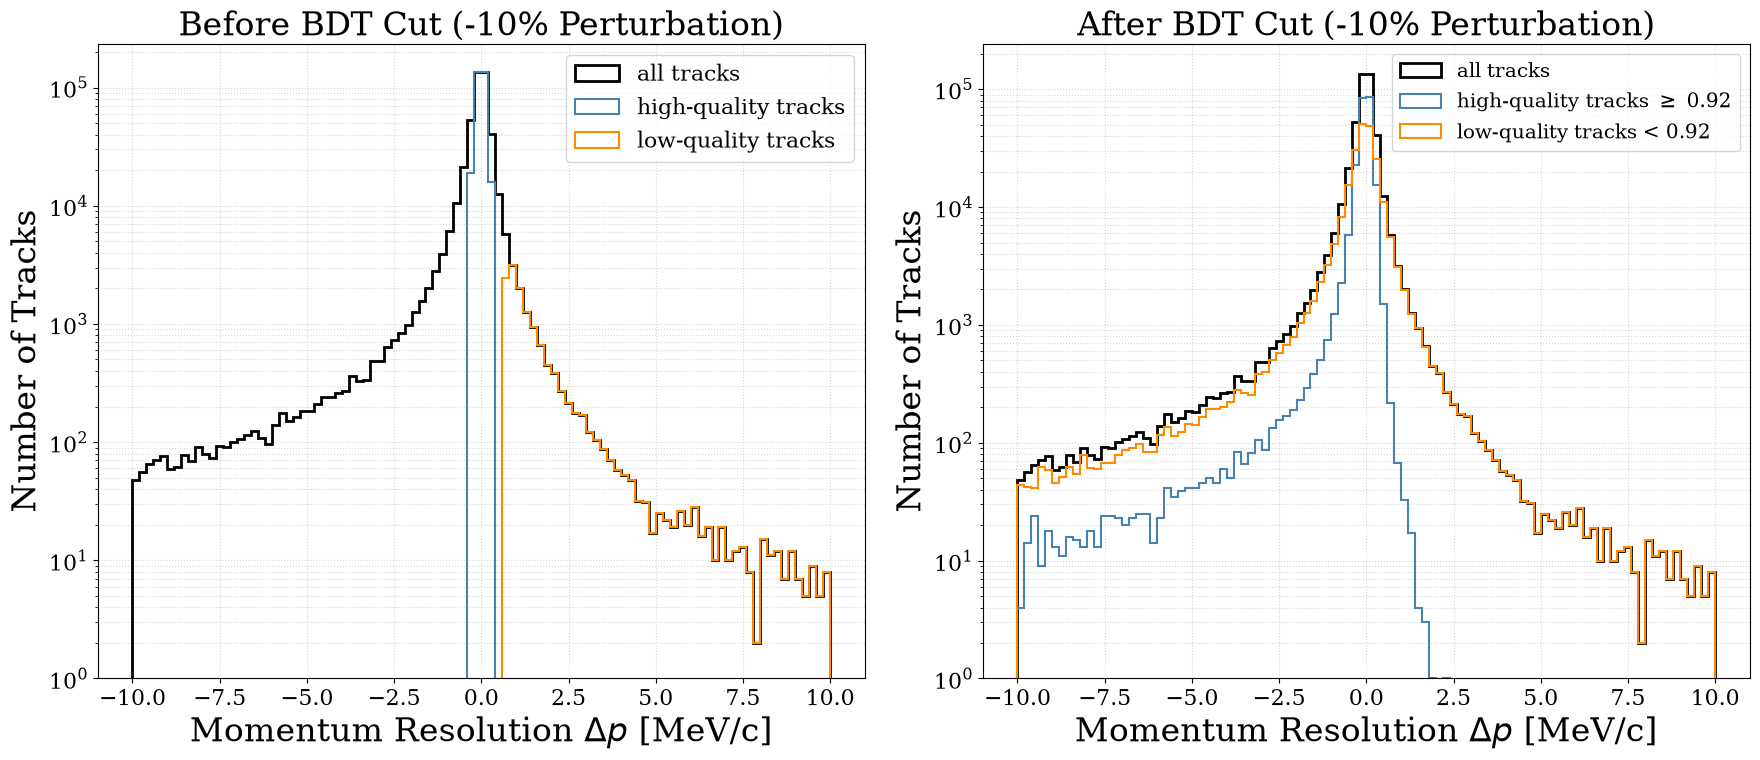

In [18]:
#Font Global Structure
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42


# Scale font sizes up Figures  after LaTeX
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})


# Setup data dictionary mapping
perturbed_files = [
    {
        "res_array": res_up, 
        "predictions": y_pred_up, 
        "high_qual_mask": (res_up > -0.25) & (res_up < 0.25), 
        "low_qual_mask": (res_up > 0.7),
        "name": "MomRes_Perturbation_Plus10",
        "title_label": "+10% Perturbation"
    },
    {
        "res_array": res_down,            
        "predictions": y_pred_down,        
        "high_qual_mask": (res_down > -0.25) & (res_down < 0.25), 
        "low_qual_mask": (res_down > 0.7), 
        "name": "MomRes_Perturbation_Minus10",
        "title_label": "-10% Perturbation"
    }
]


for file_info in perturbed_files:
    res_array = file_info["res_array"]
    bdt_scores = file_info["predictions"]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Separate tracks using your pre-trained model selection threshold
    bdt_passed = bdt_scores >= 0.92
    bdt_rejected = bdt_scores < 0.92

    
    # PANEL 1: BEFORE BDT CUT (True Training Split Layout)

    counts, bins, _ = ax1.hist(res_array, bins=100, range=(-10, 10), log=True, 
                              histtype='step', color='black', linewidth=2.0, label='all tracks')
    
    # Classic Steel Blue for the true high-quality core signal
    ax1.hist(res_array[file_info["high_qual_mask"]], bins=bins, log=True, histtype='step', color='steelblue', linewidth=1.5, label='high-quality tracks')

    # Classic Dark Orange/Yellow for the broad tracking noise
    ax1.hist(res_array[file_info["low_qual_mask"]], bins=bins, log=True, 
            histtype='step', color='darkorange', linewidth=1.5, label='low-quality tracks')
    
    ax1.set_title(f"Before BDT Cut ({file_info['title_label']})")
    ax1.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]")
    ax1.set_ylabel("Number of Tracks")
    ax1.grid(True, which="both", linestyle=":", alpha=0.5)
    ax1.set_ylim(bottom=1)
    ax1.legend(loc='upper right', fontsize=16)
    
    # PANEL 2: AFTER BDT CUT
 
    # All Tracks reference outline
    ax2.hist(res_array, bins=bins, log=True, 
             histtype='step', color='black', linewidth=2.0, label='all tracks')
    
    # Tracks the model successfully passed (Steel Blue)
    ax2.hist(res_array[bdt_passed], bins=bins, log=True, 
             histtype='step', color='steelblue', linewidth=1.5, label=r'high-quality tracks $\geq$ 0.92')
    
    # Tracks the model successfully rejected (Dark Orange)
    ax2.hist(res_array[bdt_rejected], bins=bins, log=True, 
             histtype='step', color='darkorange', linewidth=1.5, label=r'low-quality tracks < 0.92')
    
    # Fixed LaTeX label parsing formatting
    ax2.set_title(r"After BDT Cut (" + file_info['title_label'] + ")")
    ax2.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]")
    ax2.set_ylabel("Number of Tracks")
    ax2.grid(True, which="both", linestyle=":", alpha=0.5)
    ax2.set_ylim(bottom=1)
    ax2.legend(loc='upper right', fontsize=14.5)
    
    plt.tight_layout()
    
    # Save plots
    fig.savefig(f"/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/BeforeAfter_{file_info['name']}.pdf", format="pdf", bbox_inches="tight")
        
    plt.show()


### Plotting 3 different files on top of each others

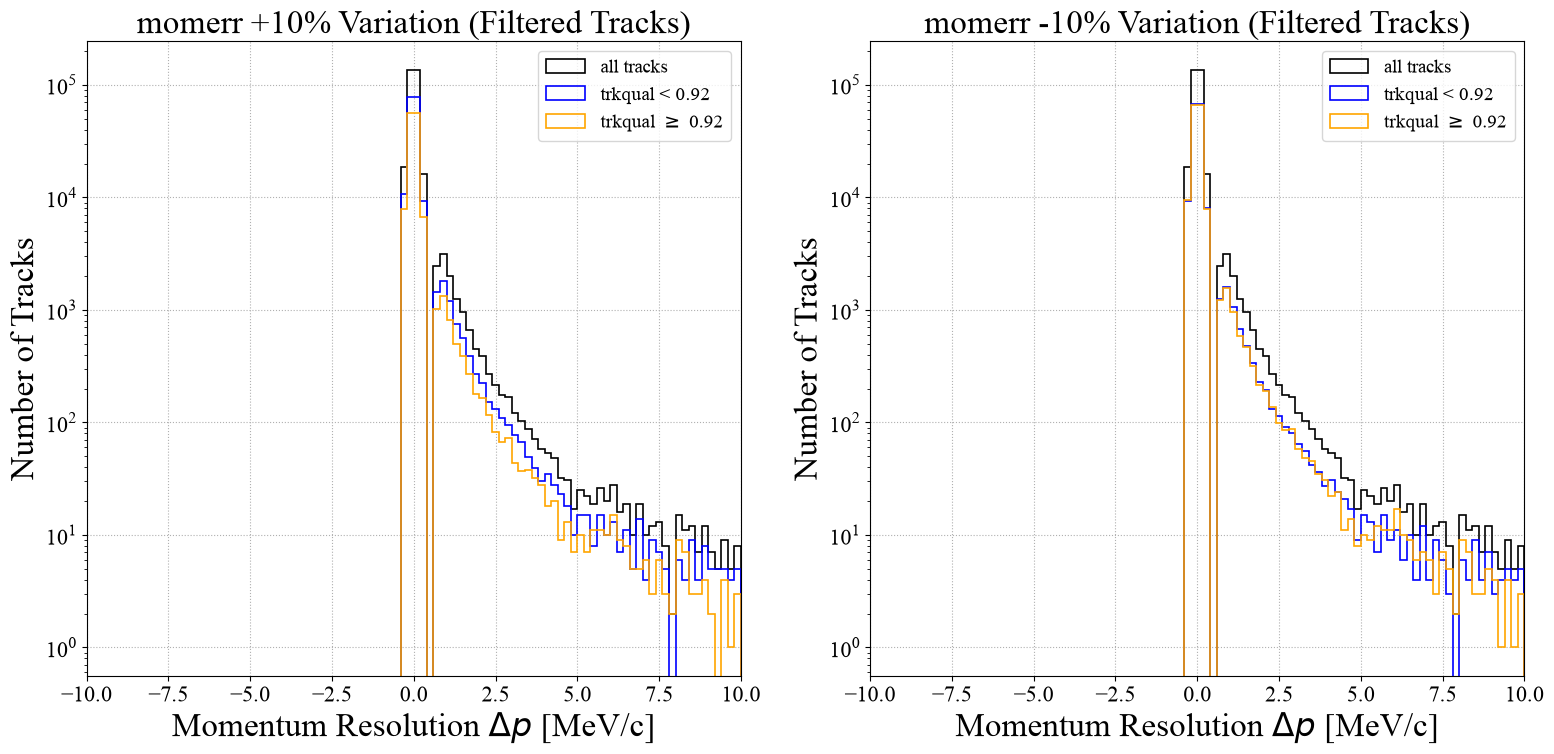

In [14]:
# Run this to match default LaTeX text
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42

# Scale font sizes up Figures  after LaTeX
plt.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14
})

# 1. Configuration Constants
n_bins = 100
bin_range = (-10.0, 10.0)

# 2. Initialize a clean 1x2 grid canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
#fig.suptitle(f"Filtered Dataset Momentum Resolution under momerr Perturbations (Cut = {TRKQUAL_CUT:.2f})", 
             #fontsize=13, fontweight='bold', y=0.98)

# 3. Setup configurations matching your up/down prediction streams
study_configs = [
    (axes[0], "momerr +10% Variation (Filtered Tracks)", y_pred_up),
    (axes[1], "momerr -10% Variation (Filtered Tracks)", y_pred_down)
]

for ax, title, y_pred_variant in study_configs:
    # Plot smooth continuous step curves using your clean filtered track resolutions
    ax.hist(mom_res_filtered, bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='black', linewidth=1.2, label='all tracks')
    
    mom_res_mask = ((mom_ent - mom_mc > -0.25) & (mom_ent - mom_mc < 0.25)) | ((mom_ent - mom_mc > 0.7))
    # ensure the mask matches the resolution array used for predictions (res_array has length 450589)
    mom_res_mask = ((res_array > -0.25) & (res_array < 0.25)) | (res_array > 0.7)
    y_pred_filtered = y_pred_variant[mom_res_mask]

    n_common = min(len(mom_res_filtered), len(y_pred_variant))
    mom_res_filtered = mom_res_filtered[:n_common]
    y_pred_variant = y_pred_variant[:n_common]

    ax.hist(mom_res_filtered[y_pred_variant < TRKQUAL_CUT], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='blue', linewidth=1.2, label=f'trkqual < {TRKQUAL_CUT:.2f}')
    
    ax.hist(mom_res_filtered[y_pred_variant >= TRKQUAL_CUT], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='orange', linewidth=1.2, label=f'trkqual $\geq$ {TRKQUAL_CUT:.2f}')
    
    # Layout and text aesthetics
    ax.set_title(title)
    ax.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]")
    ax.set_ylabel("Number of Tracks")
    ax.set_xlim(bin_range)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

## The +50% & -50% momerr perturbation analysis!

In [21]:
# 1. Print Master Headers
print(f"Total tracks in dataset: {len(y_pred_orig):,}\n")
print(f"Signal tracks: {N_signal:,}")
print(f"Background tracks: {N_background:,}\n")
print(f"{'Study Stream':<25s} {'AUC':>8s}   {'Signal Eff':>12s} {'Opt Cut':>10s} {'Mean Shift':>12s} {'% Swapped':>12s} {'HQ Recov':>8s}   {'Bkg Leak':>8s}")
print("-" * 110)

# 2. Your core study configuration loop matching your screenshot
study_variants = [
    ('momerr +50%', y_pred_up50),
    ('momerr -50%', y_pred_down50)
]

for label, scores in study_variants:
    delta = scores - y_pred_orig


    true_signal_mask = (res_original > -0.25) & (res_original < 0.25)
    true_background_mask = (res_original > 0.7)
    
    # Create a 0/1 binary label vector where Signal = 1 and Background = 0
    # Tracks falling outside both definitions are ignored in standard ROC scoring
    y_true_loop = np.zeros(len(res_original))
    y_true_loop[true_signal_mask] = 1
    y_true_loop[true_background_mask] = 0

    # Calculate fresh ROC configurations for this specific variation
    fpr, tpr, thresholds = roc_curve(y_true_loop, scores, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # Locate the optimal dynamic cut point matching your 99% background rejection target
    indices = np.where(1 - fpr >= 0.99)[0]
    cut_idx = indices[-1] if len(indices) > 0 else 0
    sig_eff = tpr[cut_idx]
    opt_cut = thresholds[cut_idx]
    
    # Track the exact track migration populations
    bdt_pass_orig = y_pred_orig >= TRKQUAL_CUT
    bdt_pass_new  = scores >= opt_cut
    
    changed = (bdt_pass_orig != bdt_pass_new).sum()
    drift_mask = bdt_pass_orig != bdt_pass_new
    
    sig_changed = (drift_mask & true_signal_mask).sum()
    bkg_changed = (drift_mask & true_background_mask).sum()
    pct_signal = (sig_changed / N_signal) * 100
    
    # Output your formatted metrics row cleanly
    print(f"{label:<25s} {auc_score:>8.4f} {sig_eff*100:>11.2f}% {opt_cut:>10.4f} {delta.mean():>12.6f} {pct_signal:>11.2f}% {sig_changed:>8,} {bkg_changed:>8,}")

Total tracks in dataset: 452,686

Signal tracks: 303,991
Background tracks: 13,449

Study Stream                   AUC     Signal Eff    Opt Cut   Mean Shift    % Swapped HQ Recov   Bkg Leak
--------------------------------------------------------------------------------------------------------------
momerr +50%                 0.7558        5.89%     0.9922    -0.128417       51.41%  156,285      135
momerr -50%                 0.7548        5.34%     0.9985     0.139402       51.96%  157,949      134


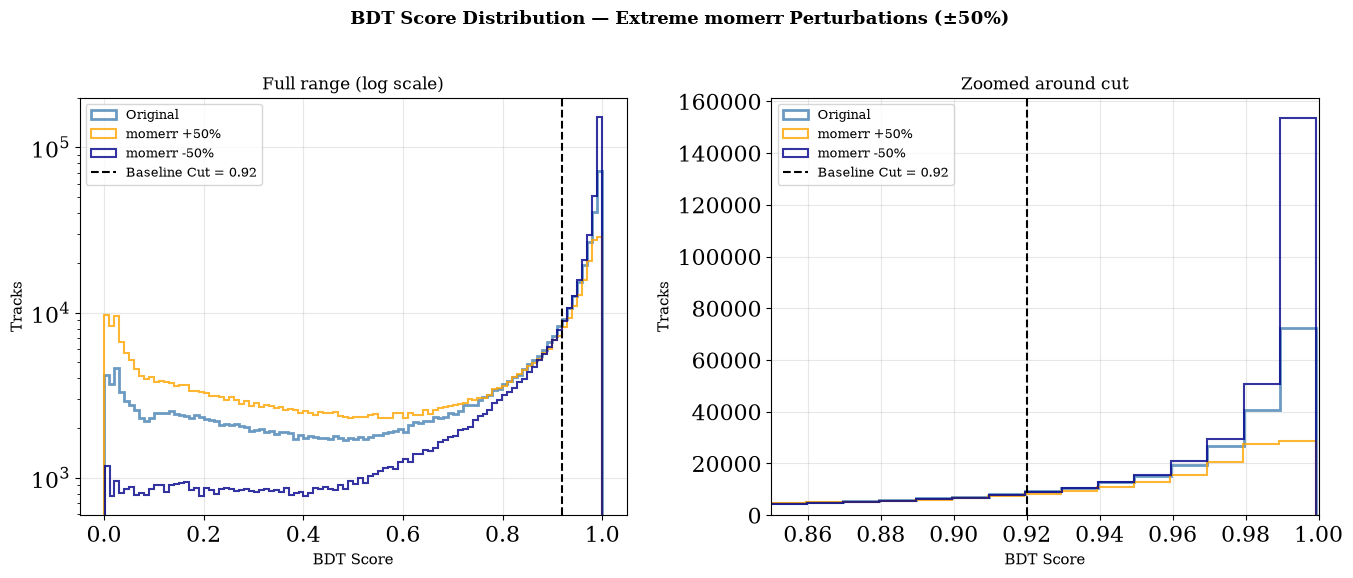

In [22]:
datasets = [
    (y_pred_orig,    'Original',    'steelblue', 'step', 2.0),
    (y_pred_up50,    'momerr +50%', 'orange',    'step', 1.5),
    (y_pred_down50,  'momerr -50%', 'darkblue',  'step', 1.5),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BDT Score Distribution — Extreme momerr Perturbations (±50%)", fontsize=13, fontweight='bold', y=0.98)

# 2. Loop through axes for full range vs zoomed view
for ax, title, xlim in zip(axes, 
                           ['Full range (log scale)', 'Zoomed around cut'], 
                           [None, (0.85, 1.0)]):
    
    for scores, label, color, htype, linewidth in datasets:
        ax.hist(scores, bins=100, color=color, histtype=htype, 
                linewidth=linewidth, label=label, alpha=0.8)
        
    # use the active global TRKQUAL_CUT constant
    ax.axvline(TRKQUAL_CUT, color='black', linestyle='--', 
               linewidth=1.5, label=f'Baseline Cut = {TRKQUAL_CUT:.2f}')
    
    ax.set_xlabel("BDT Score", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

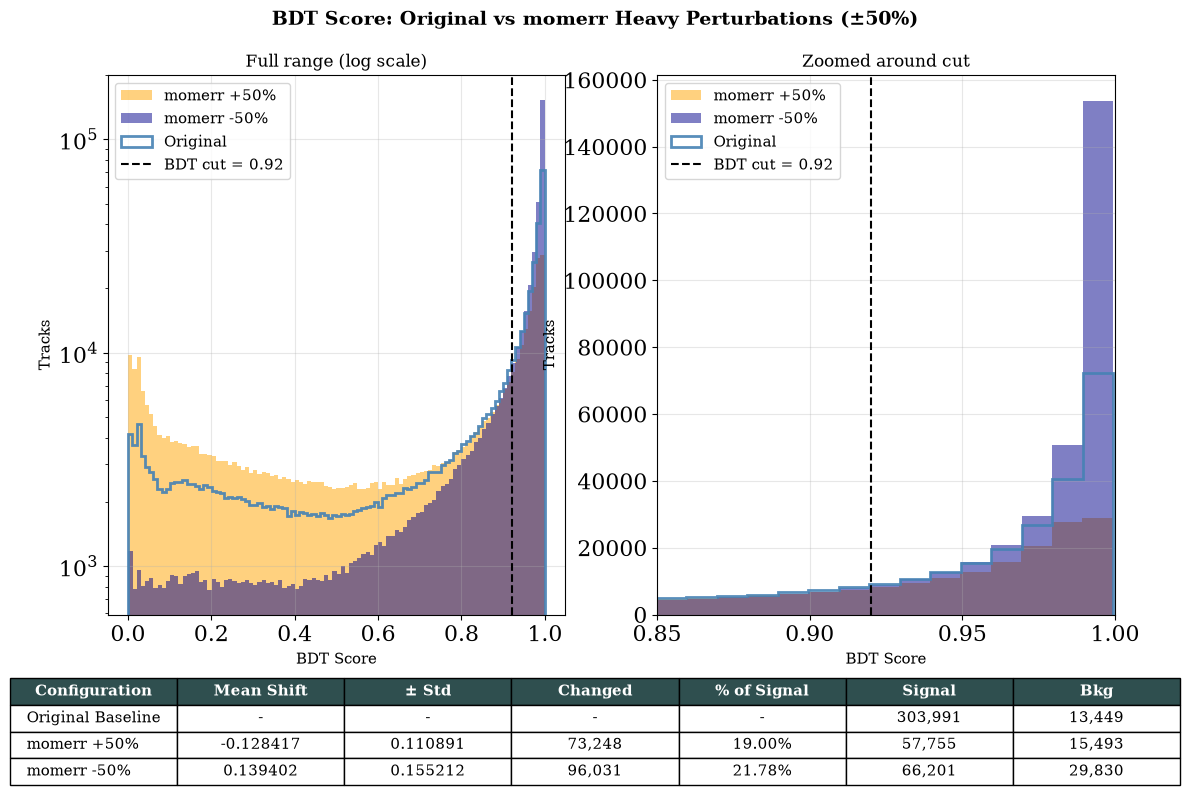

In [25]:
# 1. build all the required matrices
# Calculations for momerr +50%
bdt_pass_orig = y_pred_orig >= TRKQUAL_CUT
bdt_pass_up50 = y_pred_up50 >= TRKQUAL_CUT
changed_up50  = (bdt_pass_orig != bdt_pass_up50).sum()

drift_mask_up50 = bdt_pass_orig != bdt_pass_up50
sig_up50 = ((drift_mask_up50) & (y_true_loop == 1)).sum()
bkg_up50 = ((drift_mask_up50) & (y_true_loop == 0)).sum()
delta_up50 = y_pred_up50 - y_pred_orig

# Calculations for momerr -50%
bdt_pass_down50 = y_pred_down50 >= TRKQUAL_CUT
changed_down50  = (bdt_pass_orig != bdt_pass_down50).sum()

drift_mask_down50 = bdt_pass_orig != bdt_pass_down50
sig_down50 = ((drift_mask_down50) & (y_true_loop == 1)).sum()
bkg_down50 = ((drift_mask_down50) & (y_true_loop == 0)).sum()
delta_down50 = y_pred_down50 - y_pred_orig

# 2. Plot generator block
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.suptitle("BDT Score: Original vs momerr Heavy Perturbations (±50%)", fontsize=14, fontweight='bold', y=0.98)

for ax, title, xlim in zip(axes, ['Full range (log scale)', 'Zoomed around cut'], [None, (0.85, 1.0)]):
    ax.hist(y_pred_up50, bins=100, alpha=0.5, color='orange', label='momerr +50%')
    ax.hist(y_pred_down50, bins=100, alpha=0.5, color='darkblue', label='momerr -50%')
    ax.hist(y_pred_orig, bins=100, alpha=0.9, color='steelblue', label='Original', histtype='step', linewidth=2)
    
    ax.axvline(TRKQUAL_CUT, color='black', linestyle='--', linewidth=1.5, label=f'BDT cut = {TRKQUAL_CUT:.2f}')
    ax.set_xlabel("BDT Score", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(alpha=0.3)
    
    if xlim:
        ax.set_xlim(xlim)
    else:
        ax.set_yscale('log')

# 3. Summary table
table_data = [
    ["Original Baseline", "-", "-", "-", "-", f"{N_signal:,}", f"{N_background:,}"],
    ["momerr +50%", f"{delta_up50.mean():.6f}", f"{delta_up50.std():.6f}", f"{changed_up50:,}", f"{sig_up50/N_signal*100:.2f}%", f"{sig_up50:,}", f"{bkg_up50:,}"],
    ["momerr -50%", f"{delta_down50.mean():.6f}", f"{delta_down50.std():.6f}", f"{changed_down50:,}", f"{sig_down50/N_signal*100:.2f}%", f"{sig_down50:,}", f"{bkg_down50:,}"]
]

columns = ["Configuration", "Mean Shift", "± Std", "Changed", "% of Signal", "Signal", "Bkg"]

table_ax = fig.add_axes([0.05, -0.22, 0.9, 0.18])
table_ax.axis('off')

summary_table = table_ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11)
summary_table.scale(1.0, 1.6)

# Table Header Aesthetics
for (row, col), cell in summary_table.get_celld().items():
    if col == 0 and row > 0:
        cell.set_text_props(ha='left')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2f4f4f')

plt.subplots_adjust(bottom=0.05)
plt.show()

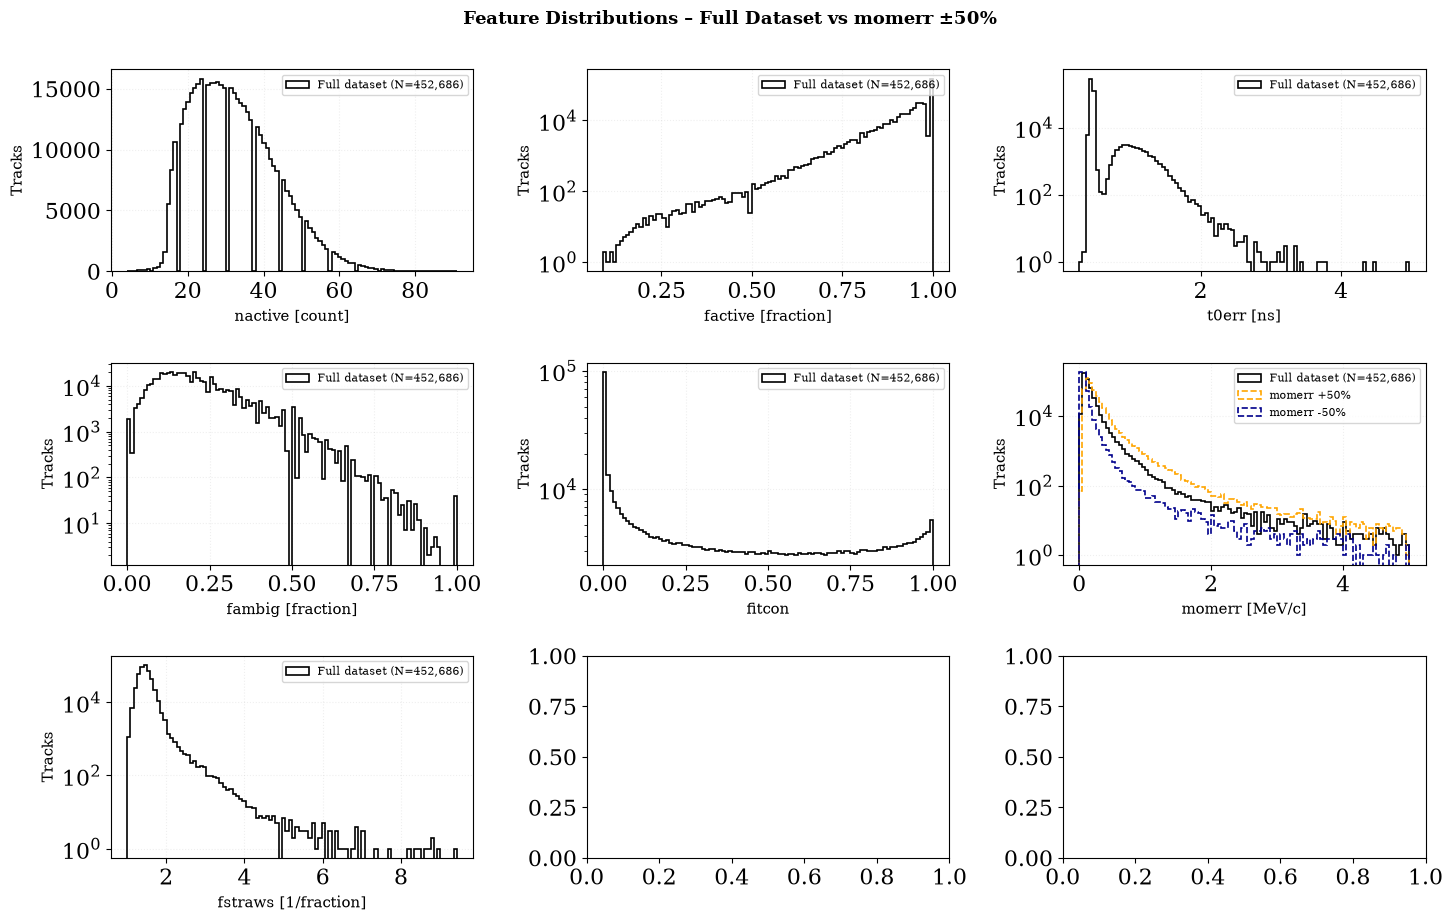

In [26]:
units = [" [count]", " [fraction]", " [ns]", " [fraction]", "", " [MeV/c]", " [1/fraction]"]
log_flags = [False, True, True, True, True, True, True] 
momerr_idx = input_var_names.index('momerr')

fig, axs = plt.subplots(3, 3, figsize=(15, 9.5))
fig.subplots_adjust(hspace=0.45, wspace=0.25)
fig.suptitle("Feature Distributions – Full Dataset vs momerr ±50%", fontsize=13, fontweight='bold', y=0.98)

# 2. Polished data visualization loop
for i_var, name in enumerate(input_var_names):
    ax = axs.flatten()[i_var]
    
    # Calculate limits dynamically from the data arrays
    lims = (float(x_original_full[:, i_var].min()), float(x_original_full[:, i_var].max()))
    if name == "momerr": lims = (0, 5)  # Zooms into the critical physics tail region
    
    # Draw original baseline control dataset
    ax.hist(x_original_full[:, i_var], bins=100, range=lims, log=log_flags[i_var], 
            histtype='step', color='black', label=f'Full dataset (N={len(x_original_full):,})', linewidth=1.2)
    
    # Overlay extreme perturbations using the active 50% memory arrays
    if i_var == momerr_idx:
        ax.hist(x_up50[:, i_var], bins=100, range=lims, log=True, histtype='step', color='orange', label='momerr +50%', linestyle='--', linewidth=1.2)
        ax.hist(x_down50[:, i_var], bins=100, range=lims, log=True, histtype='step', color='darkblue', label='momerr -50%', linestyle='--', linewidth=1.2)
        
    ax.set_xlabel(f"{name}{units[i_var]}", fontsize=11)
    ax.set_ylabel("Tracks", fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2, linestyle=':')

plt.tight_layout()
plt.show()

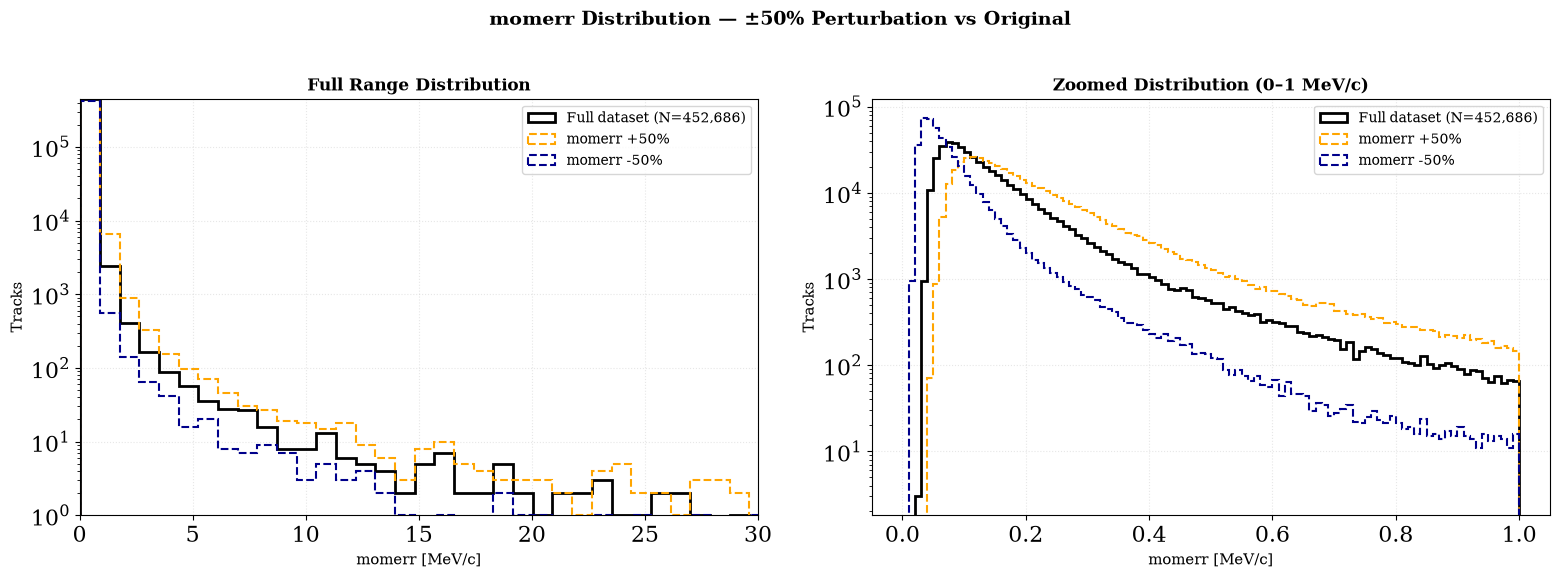

In [27]:
i = input_var_names.index('momerr')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_params_50 = [
    (x_original_full[:, i], 'black', f'Full dataset (N={len(x_original_full):,})', '-', 2.0),
    (x_up50[:, i], 'orange', 'momerr +50%', '--', 1.5),
    (x_down50[:, i], 'darkblue', 'momerr -50%', '--', 1.5)
]

# Calculate perfect chart range boundaries directly from the baseline data arrays
f_min, f_max = float(x_original_full[:, i].min()), float(x_original_full[:, i].max())

# Loop through both axes to apply the data overlays cleanly
for ax in [ax1, ax2]:
    for data, color, label, style, lw in plot_params_50:
        hist_range = (f_min, f_max) if ax == ax1 else (0.0, 1.0)
        
        ax.hist(data, bins=100, range=hist_range,
                histtype='step', color=color, log=True,
                label=label, linestyle=style, linewidth=lw)
        
    ax.set_ylabel("Tracks", fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(alpha=0.3, linestyle=':')

# 3. Individual Panel Customization 
ax1.set_title("Full Range Distribution", fontweight='bold', fontsize=12)
ax1.set_xlabel("momerr [MeV/c]", fontsize=11)
ax1.set_xlim(0, 30) 
ax1.margins(0)

ax2.set_title("Zoomed Distribution (0–1 MeV/c)", fontweight='bold', fontsize=12)
ax2.set_xlabel("momerr [MeV/c]", fontsize=11)

fig.suptitle("momerr Distribution — ±50% Perturbation vs Original", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

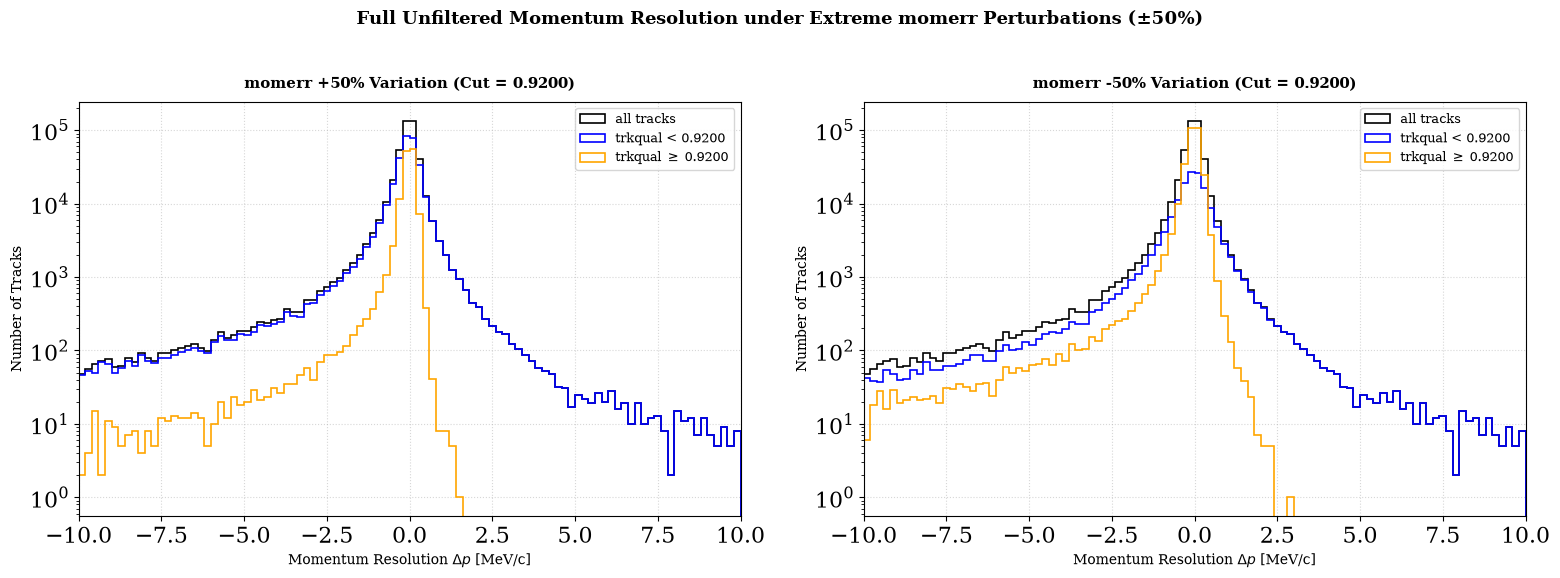

In [28]:
# 1. Configuration Constants 
n_bins = 100
bin_range = (-10.0, 10.0)

# 2. Extract full unfiltered arrays and calculate true unfiltered momentum resolution
with uproot.open(f"{BASE_PATH}:{TREE_NAME}") as tree:
    arrays = tree.arrays(library="np")
    
    # Extract raw components for the x-axis mapping
    mom_ent_unfilt = np.sqrt(arrays['trk_ent.mom.fCoordinates.fX']**2 + arrays['trk_ent.mom.fCoordinates.fY']**2 + arrays['trk_ent.mom.fCoordinates.fZ']**2)
    mom_mc_unfilt  = np.sqrt(arrays['trk_ent_mc.mom.fCoordinates.fX']**2 + arrays['trk_ent_mc.mom.fCoordinates.fY']**2 + arrays['trk_ent_mc.mom.fCoordinates.fZ']**2)
    mom_res_unfilt = mom_ent_unfilt - mom_mc_unfilt
    
    # Unpack native features sequentially
    nactive = arrays['trk.nactive']
    nhits   = arrays['trk.nhits']
    factive = nactive / nhits
    fambig  = arrays['trk.nnullambig'] / nactive
    fstraws = arrays['trk.nmatactive'] / nactive
    t0err   = arrays['trk_ent_pars.t0err']
    fitcon  = arrays['trk.fitcon']
    raw_momerr = arrays['trk_ent.momerr']

# 3. Initialize a clean 1x2 comparison grid canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Full Unfiltered Momentum Resolution under Extreme momerr Perturbations (±50%)", 
             fontsize=13, fontweight='bold', y=0.98)

# 4. Loop through both up and down scales using the exact dynamic cuts from your table
# We match the cut precisely to the optimized value needed to keep 99% rejection
study_configs = [
    (axes[0], "momerr +50% Variation", raw_momerr * 1.50, 0.92),
    (axes[1], "momerr -50% Variation", raw_momerr * 0.50, 0.92)
]

for ax, title, perturbed_momerr, dynamic_cut in study_configs:
    # Build the feature matrix dynamically for this specific modification stream
    x_unfilt = np.vstack((nactive, factive, t0err, fambig, fitcon, perturbed_momerr, fstraws)).T
    y_pred_unfilt = model.predict_proba(x_unfilt)[:, 1]
    
    # Plot smooth continuous step curves
    ax.hist(mom_res_unfilt, bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='black', linewidth=1.2, label='all tracks')
    
    ax.hist(mom_res_unfilt[y_pred_unfilt < dynamic_cut], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='blue', linewidth=1.2, label=f'trkqual < {dynamic_cut:.4f}')
    
    ax.hist(mom_res_unfilt[y_pred_unfilt >= dynamic_cut], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='orange', linewidth=1.2, label=f'trkqual $\geq$ {dynamic_cut:.4f}')
    
    # Formatting adjustments per panel
    ax.set_title(f"{title} (Cut = {dynamic_cut:.4f})", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontsize=10)
    ax.set_ylabel("Number of Tracks", fontsize=10)
    ax.set_xlim(bin_range)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 317440 but size of corresponding boolean axis is 452686

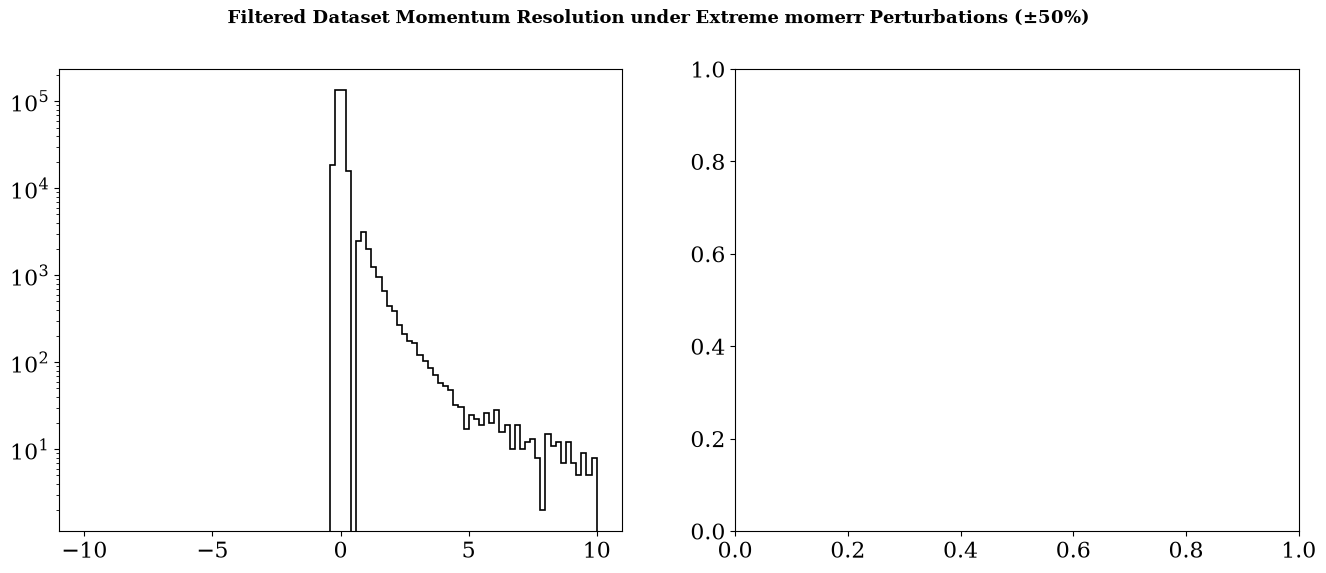

In [29]:
# 1. Configuration Constants 
n_bins = 100
bin_range = (-10.0, 10.0)

# 2. Initialize a clean 1x2 grid canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Filtered Dataset Momentum Resolution under Extreme momerr Perturbations (±50%)", 
             fontsize=13, fontweight='bold', y=0.98)

# 3. Setup configurations matching the 50% dynamic cuts and prediction streams
study_configs = [
    (axes[0], "momerr +50% Variation (Filtered Tracks)", y_pred_up50, 0.92),
    (axes[1], "momerr -50% Variation (Filtered Tracks)", y_pred_down50, 0.92)
]

for ax, title, y_pred_variant, Static_cut in study_configs:
    # Plot smooth continuous step curves using your clean filtered track resolutions
    ax.hist(mom_res_filtered, bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='black', linewidth=1.2, label='all tracks')
    
    ax.hist(mom_res_filtered[y_pred_variant < Static_cut], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='blue', linewidth=1.2, label=f'trkqual < {dynamic_cut:.4f}')
    
    ax.hist(mom_res_filtered[y_pred_variant >= Static_cut], bins=n_bins, range=bin_range, log=True, 
            histtype='step', color='orange', linewidth=1.2, label=f'trkqual $\geq$ {Static_cut:.4f}')
    
    # Layout and text aesthetics
    ax.set_title(f"{title}\n(Static Cut = {Static_cut:.2f})", fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel("Momentum Resolution $\Delta p$ [MeV/c]", fontsize=10)
    ax.set_ylabel("Number of Tracks", fontsize=10)
    ax.set_xlim(bin_range)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()